# Instacart Market Basket Analysis — Final Project Notebook

**Course:** CSCE 676, Data Mining and Analysis (Spring 2026)  
**Author:** Hari Krishna Shivanathri  
**Repository:** [github.com/harikrishna-TAMU/InstaCart-Market-Basket-Analysis](https://github.com/harikrishna-TAMU/InstaCart-Market-Basket-Analysis)

> 👉 **This is the main notebook for grading.** I also kept my Checkpoint 1 and Checkpoint 2 notebooks in `checkpoints/` so you can see how my thinking evolved over the semester, but everything important ended up here.

## What this project is about

I worked with Instacart's grocery-order dataset (3M+ orders from ~200K users) and ended up asking three questions about it:

1. Which products are bought *together* in a way that's actually surprising, not just popular? I tackle this with **Apriori + Association Rules**.
2. Can the *names* of products tell us something the existing aisle and department labels don't? I use **TF-IDF + K-Means** for that.
3. Do users have shopping *patterns over time* (across multiple trips) that a one-basket-at-a-time model would miss? For this I went outside the course and used **PrefixSpan**.

I picked these three because they each look at the same data from a different angle: one is about *what goes together*, one is about *what is similar*, and one is about *what comes next*.

## Why I picked this project

Online grocery is a setting where even small recommendation wins matter a lot, because the volumes are huge. Sitting on top of the same Instacart dataset there are three real product problems I kept thinking about:

- **Cross-sell.** When someone drops *Organic Strawberries* into their cart, what's a good next suggestion? Just showing the most popular item ("everyone buys bananas") is useless as a recommendation. I want to find co-purchases that are actually surprising, not just common.
- **How the catalog is organized.** Instacart has 21 departments and 134 aisles, but those labels are rigid. A name like "Organic Greek Whole Milk Vanilla Yogurt" tells you about organic preference, dairy type, and flavor at the same time, and an aisle can only put it in one place. There's information sitting in product names that the official taxonomy throws away.
- **Bringing users back.** Around 60% of items in a typical Instacart basket are reorders, so people clearly have habits. If I can model the *sequence* a user goes through across multiple trips ("produce, then dairy, then snacks") then I can recommend categories before they even open the app, instead of only ranking items inside the current basket.

The first two questions map onto course material (frequent itemset mining and text clustering). The third one really needs a sequential method, which is why I went outside the course for PrefixSpan.

## My research questions

| RQ | Question | Technique | Type |
|---|---|---|---|
| **RQ1** | What co-purchase patterns have the highest predictive lift? | Apriori + Association Rules | Course |
| **RQ2** | Do product names reveal product groupings that the aisle/department taxonomy doesn't already capture? | TF-IDF + K-Means | Course |
| **RQ3** | What sequences of purchases show up across users' shopping trips? | PrefixSpan | External |

This satisfies the requirement of using at least two in-class techniques and at least one external technique.

## The dataset

I used the [Instacart Market Basket Analysis](https://www.kaggle.com/c/instacart-market-basket-analysis) dataset, originally a 2017 Kaggle competition and since then used in SIGIR/KDD work (most recently *"An Embedding-Based Grocery Search Model at Instacart"*, SIGIR eCom 2022).

A quick rundown:
- 3,421,083 orders from roughly 206K anonymized users
- 49,688 products organized into 134 aisles and 21 departments
- Tables I actually use: `orders.csv`, `order_products__train.csv`, `order_products__prior.csv`, `products.csv`, `aisles.csv`, `departments.csv`

To reproduce: grab the CSVs from Kaggle and drop them in the same folder as this notebook (or change the paths in the data-loading cell). I didn't commit the raw data because it's a few GB; there's a short note in `data/README.md` about how to download it.

## How the notebook is laid out

1. Setup and data loading
2. EDA — four findings that each motivate one of the RQs
3. RQ1: Apriori + Association Rules
4. RQ2: TF-IDF + K-Means
5. RQ3: PrefixSpan
6. Putting the three RQs together
7. Conclusions, limitations, what I'd try next
8. References and environment export

---

## 1. Setup

Two packages aren't part of the default Colab stack and need to be installed: `mlxtend` (Apriori, association rules) and `prefixspan` (sequential pattern mining). The next cell uses `%pip`, which installs into the notebook kernel's Python (not whatever shell `pip` happens to point to). **Locally:** run `python3 -m pip install -r requirements.txt` once so your editor's Python also has these packages (fixes import hints like "could not be resolved"). After that the imports are pretty standard. I also fix a random seed so anything that involves sampling or K-Means initialization is reproducible.

In [1]:
%pip install mlxtend prefixspan -q
%pip install -U pip matplotlib
%pip install "pyparsing<3.1"


Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
  Attempting uninstall: pyparsing
    Found existing installation: pyparsing 3.3.2
    Uninstalling pyparsing-3.3.2:
      Successfully uninstalled pyparsing-3.3.2
Note: you may need to restart the kernel to use updated packages.


In [2]:
import warnings
warnings.simplefilter("ignore")
warnings.simplefilter('ignore')
warnings.simplefilter('ignore')
warnings.simplefilter('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

from prefixspan import PrefixSpan

SEED = 42
np.random.seed(SEED)

plt.style.use("ggplot")
sns.set_palette("tab10")

print("Environment ready.")

Environment ready.


---

## 2. Loading the data

Instacart's data lives in five relational CSV files. To keep the rest of the notebook simple I join everything I need into one big `master` DataFrame for the labelled `train` orders. After the merge each row is "an item in an order", and on that row I have the order, the user, the product (with its name, aisle, and department), and the order-level timing info.

```
order_products__train  ───┐
products + aisles + dept ─┼─►  master
orders (train rows only) ─┘
```

One mistake I made in Checkpoint 1 that's worth flagging: I had truncated `orders.csv` and `order_products__train.csv` to 100K rows each *separately* before merging, which lined up the wrong rows and gave me ~97K NaN rows on the user/timestamp side. In this version I load the full tables and use an `inner` merge on `order_id`, which is what I should have done from the start.

In [3]:
orders = pd.read_csv("orders.csv")
products = pd.read_csv("products.csv")
aisles = pd.read_csv("aisles.csv")
departments = pd.read_csv("departments.csv")
order_products_train = pd.read_csv("order_products__train.csv")

products_full = products.merge(aisles, on="aisle_id").merge(departments, on="department_id")

train_orders = orders[orders["eval_set"] == "train"]
master = (
    order_products_train
    .merge(products_full, on="product_id", how="left")
    .merge(train_orders, on="order_id", how="inner")
    .drop(columns=["eval_set"])
)

print(f"Master DataFrame: {master.shape[0]:,} rows  x  {master.shape[1]} columns")
print(f"Unique orders   : {master['order_id'].nunique():,}")
print(f"Unique users    : {master['user_id'].nunique():,}")
print(f"Unique products : {master['product_id'].nunique():,}")
print(f"Missing values  : {int(master.isnull().sum().sum())}")
master.head(5)

Master DataFrame: 1,384,617 rows  x  14 columns
Unique orders   : 131,209
Unique users    : 131,209
Unique products : 39,123
Missing values  : 0


,order_id,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id,aisle,department,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,1,49302,1,1,Bulgarian Yogurt,120,16,yogurt,dairy eggs,112108,4,4,10,9.0
1,1,11109,2,1,Organic 4% Milk Fat Whole Milk Cottage Cheese,108,16,other creams cheeses,dairy eggs,112108,4,4,10,9.0
2,1,10246,3,0,Organic Celery Hearts,83,4,fresh vegetables,produce,112108,4,4,10,9.0
3,1,49683,4,0,Cucumber Kirby,83,4,fresh vegetables,produce,112108,4,4,10,9.0
4,1,43633,5,1,Lightly Smoked Sardines in Olive Oil,95,15,canned meat seafood,canned goods,112108,4,4,10,9.0


---

## 3. Exploratory data analysis

I did a lot of exploration along the way (most of it sits in the checkpoint notebooks), but for this final notebook I'm only keeping the four findings that I actually use later. Each one is the reason a particular RQ is worth asking. If the pattern wasn't there, the corresponding method wouldn't have anything to find.

| Finding | What it says | Why it matters |
|---|---|---|
| 3.1 Item popularity is a long tail | A handful of products dominate, most are rare | I need a min-support threshold for RQ1 |
| 3.2 The user-item matrix is 99.9% sparse | Most users buy a tiny fraction of the catalog | I need to filter to top products (RQ1) or abstract to departments (RQ3) |
| 3.3 Users shop on weekly rhythms | Time-between-orders peaks at 7, 14, 21, 28, 30 days | There's a temporal signal worth modelling, hence RQ3 |
| 3.4 Product names are keyword-rich | Words like "Organic", "Greek", "Gluten-Free" recur across thousands of products | Text features actually work, hence RQ2 |

### 3.1 Item popularity is a long tail, baskets are small

On the left plot below I rank all the products by frequency on a log y-axis. The roughly straight diagonal line is the giveaway that this is a power-law long tail: a few products are bought all the time, and a huge number of products are bought rarely. On the right is the basket-size distribution. Most orders have somewhere between 5 and 15 items, and the mean comes out to about 10.6.

This combination is actually good news for Apriori. Some products show up in well over 1% of orders so a 1% support threshold has something to bite on, and basket sizes stay small enough that the candidate-generation step doesn't blow up.

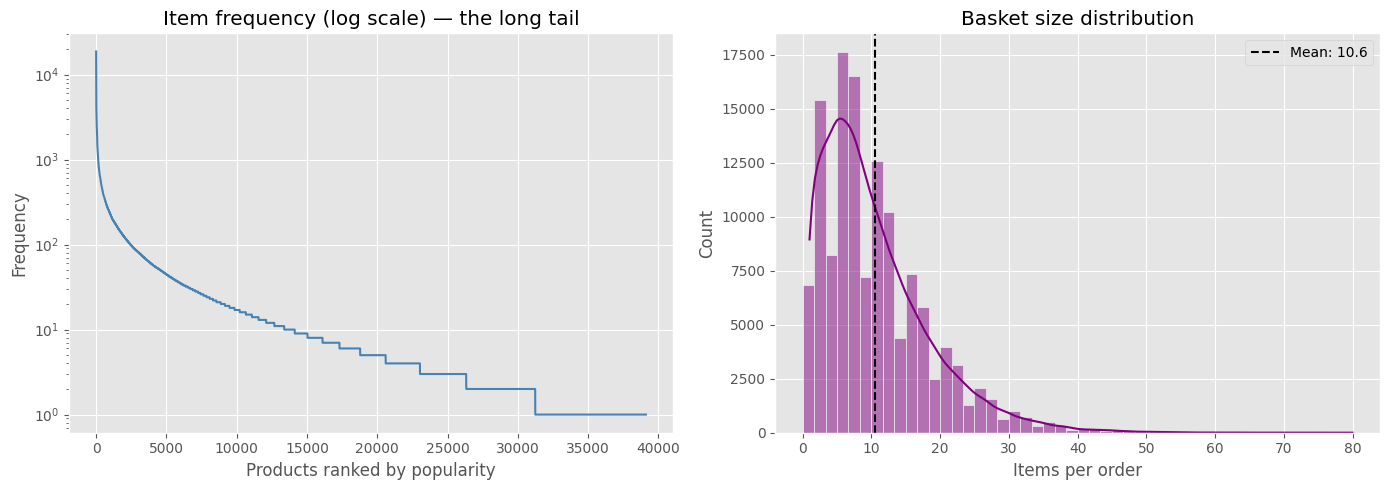

Top 10 products account for 6.9% of all item appearances.
Median item frequency: 5
Mean basket size     : 10.6


In [4]:
item_counts = master["product_name"].value_counts()
basket_sizes = master.groupby("order_id")["product_id"].count()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(x=range(len(item_counts)), y=item_counts.values, ax=axes[0], color="steelblue")
axes[0].set_yscale("log")
axes[0].set_title("Item frequency (log scale) — the long tail")
axes[0].set_xlabel("Products ranked by popularity")
axes[0].set_ylabel("Frequency")

sns.histplot(basket_sizes, bins=30, binrange=(0, 50), kde=True, ax=axes[1], color="purple")
axes[1].axvline(basket_sizes.mean(), color="black", linestyle="--",
                label=f"Mean: {basket_sizes.mean():.1f}")
axes[1].set_title("Basket size distribution")
axes[1].set_xlabel("Items per order")
axes[1].legend()

plt.tight_layout()
plt.show()

top10_share = item_counts.head(10).sum() / item_counts.sum() * 100
print(f"Top 10 products account for {top10_share:.1f}% of all item appearances.")
print(f"Median item frequency: {item_counts.median():.0f}")
print(f"Mean basket size     : {basket_sizes.mean():.1f}")

### 3.2 The user-item matrix is 99.9% sparse

To get a sense of just how sparse the data is, I take a sample of 5,000 orders, pivot to a binary order-by-product matrix, and count the filled cells. Out of about 62 million possible (order, product) entries only around 52K are non-zero, which works out to a sparsity of 99.92%. The `spy` plot below shows how empty that actually looks.

The takeaway is that I can't run a dense Apriori on all 49K products and I can't run plain collaborative filtering without a lot of preprocessing. So for RQ1 I'm going to filter to the top-N most frequent products, and for RQ3 I'm going to roll items up to the department level. Both of these come back later.

User-item matrix : 5,000 orders  x  12,388 products
Possible cells   : 61,940,000
Filled cells     : 52,484
Sparsity         : 99.92%


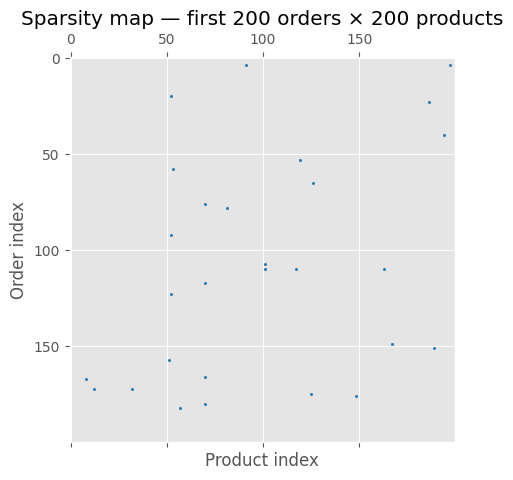

In [5]:
sample_orders = master["order_id"].unique()[:5000]
sparse_sub = master[master["order_id"].isin(sample_orders)]
ui_matrix = sparse_sub.groupby(["order_id", "product_id"]).size().unstack(fill_value=0)

total = ui_matrix.shape[0] * ui_matrix.shape[1]
nonzero = int(np.count_nonzero(ui_matrix.values))
sparsity = (1 - nonzero / total) * 100

print(f"User-item matrix : {ui_matrix.shape[0]:,} orders  x  {ui_matrix.shape[1]:,} products")
print(f"Possible cells   : {total:,}")
print(f"Filled cells     : {nonzero:,}")
print(f"Sparsity         : {sparsity:.2f}%")

plt.figure(figsize=(9, 5))
plt.spy(ui_matrix.iloc[:200, :200], markersize=1)
plt.title("Sparsity map — first 200 orders × 200 products")
plt.xlabel("Product index")
plt.ylabel("Order index")
plt.show()

### 3.3 Users shop on weekly rhythms

The histogram below is over the `days_since_prior_order` column from the full `orders.csv` (not just the train split). The sharp spikes at 7, 14, 21, 28, and a smaller one at 30 days are the obvious thing to notice. The 7-day peak is roughly 3 times higher than the average day.

Apriori is going to throw all of this away because it treats every basket as an independent unordered set. To me that was the strongest argument for adding a sequential method to the project, which is what RQ3 is for.

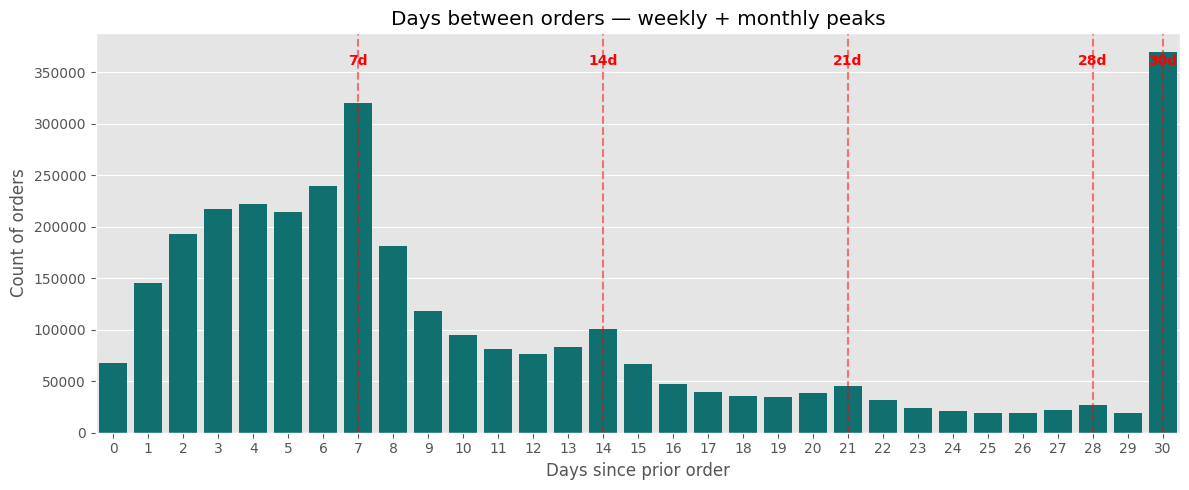

7-day peak     : 320,608 orders (3.1x the average day)
Reorder rate   : 59.9%


In [6]:
days_dist = orders["days_since_prior_order"].dropna()
counts = days_dist.value_counts().sort_index()

plt.figure(figsize=(12, 5))
sns.barplot(x=counts.index.astype(int), y=counts.values, color="teal")
for peak in [7, 14, 21, 28, 30]:
    plt.axvline(x=peak, color="red", linestyle="--", alpha=0.5)
    plt.text(peak, plt.ylim()[1] * 0.92, f"{peak}d",
             color="red", fontweight="bold", ha="center")
plt.title("Days between orders — weekly + monthly peaks")
plt.xlabel("Days since prior order")
plt.ylabel("Count of orders")
plt.tight_layout()
plt.show()

peak_7 = counts.get(7.0, 0)
print(f"7-day peak     : {peak_7:,} orders ({peak_7 / counts.mean():.1f}x the average day)")
print(f"Reorder rate   : {master['reordered'].mean():.1%}")

### 3.4 Product names are keyword-rich

If the names had been generic SKU strings then a text-clustering approach wouldn't have been worth trying. But they're not. Words like *organic*, *cheese*, *chocolate*, *gluten free*, and *greek* show up in thousands of distinct product names, which is the kind of signal TF-IDF can pick up on. The bar chart below is a quick sanity check before I commit to that approach in RQ2.

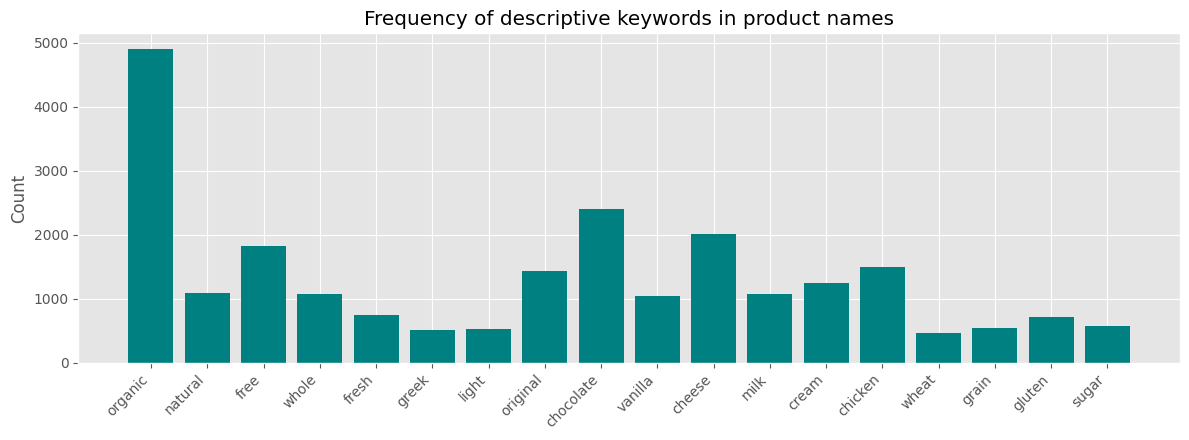

Avg name length: 4.7 words
Products containing 'Organic'  : 5,036
Products containing 'Gluten'   : 821
Products containing 'Chocolate': 2,435


In [7]:
all_words = " ".join(products_full["product_name"]).lower().split()
word_freq = Counter(all_words)

keywords = ["organic", "natural", "free", "whole", "fresh", "greek",
            "light", "original", "chocolate", "vanilla", "cheese", "milk",
            "cream", "chicken", "wheat", "grain", "gluten", "sugar"]
keyword_counts = {k: word_freq.get(k, 0) for k in keywords}

plt.figure(figsize=(12, 4.5))
plt.bar(keyword_counts.keys(), keyword_counts.values(), color="teal")
plt.title("Frequency of descriptive keywords in product names")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

n_organic = products_full["product_name"].str.contains("Organic", case=False).sum()
n_gluten  = products_full["product_name"].str.contains("Gluten",  case=False).sum()
n_choc    = products_full["product_name"].str.contains("Chocolate", case=False).sum()
print(f"Avg name length: {products_full['product_name'].str.split().str.len().mean():.1f} words")
print(f"Products containing 'Organic'  : {n_organic:,}")
print(f"Products containing 'Gluten'   : {n_gluten:,}")
print(f"Products containing 'Chocolate': {n_choc:,}")

---

## 4. RQ1: What co-purchase patterns have the highest predictive lift?

*Course technique: Apriori + Association Rules*

### What I do

The pipeline is pretty standard:

1. Keep only the 200 most frequent products. If I tried to do this with all 49K products the one-hot transaction matrix would have around 6 billion cells and Apriori's candidate generation would never finish on Colab. The top 200 still cover most of the interesting co-purchase space.
2. Build a transaction matrix by grouping the master DataFrame by `order_id` and one-hot encoding which of those 200 products are in each order.
3. Run Apriori with `min_support = 0.01`, so a rule has to hold in at least 1% of orders.
4. Pull out association rules with `lift >= 1.5` and sort them by lift.

### Why lift instead of confidence

Confidence is `P(B | A)`, which is the obvious measure but it's misleading when B is just popular on its own. A rule with confidence 0.9 isn't impressive if B shows up in 90% of *all* orders anyway. Lift normalizes for this by dividing by `P(B)`, so a lift of 3 means "this co-purchase is 3 times more likely than you'd expect if A and B were independent". Bananas have huge confidence on the right-hand side of basically every rule because everyone buys bananas, but they don't have high lift.

### Why Apriori instead of FP-Growth

Both find the same frequent itemsets. I went with Apriori because the level-by-level candidate generation is easier to inspect and step through if something looks weird. FP-Growth would be faster, but at this scale (200 products, ~131K orders) Apriori finishes in seconds either way, so the speed gain wasn't worth giving up the readability.

In [8]:
TOP_N = 200
top_products = master["product_name"].value_counts().head(TOP_N).index.tolist()

top_df = master[master["product_name"].isin(top_products)]
baskets = top_df.groupby("order_id")["product_name"].apply(list).reset_index()

te = TransactionEncoder()
te_array = te.fit_transform(baskets["product_name"])
basket_df = pd.DataFrame(te_array, columns=te.columns_)

density = basket_df.values.sum() / (basket_df.shape[0] * basket_df.shape[1]) * 100
print(f"Transactions       : {basket_df.shape[0]:,} orders")
print(f"Items per row      : {basket_df.shape[1]} (top-{TOP_N} products)")
print(f"Matrix density     : {density:.2f}%")

Transactions       : 102,698 orders
Items per row      : 200 (top-200 products)
Matrix density     : 2.02%


In [9]:
freq_items = apriori(basket_df, min_support=0.01, use_colnames=True)
rules = (
    association_rules(freq_items, metric="lift", min_threshold=1.5)
    .sort_values("lift", ascending=False)
    .reset_index(drop=True)
)

print(f"Frequent itemsets found : {len(freq_items)}")
print(f"Rules with lift >= 1.5  : {len(rules)}")
print("\nTop 15 rules by lift:")
rules[["antecedents", "consequents", "support", "confidence", "lift"]].head(15)

Frequent itemsets found : 178
Rules with lift >= 1.5  : 52

Top 15 rules by lift:


,antecedents,consequents,support,confidence,lift
0,(Large Lemon),(Limes),0.015531,0.196066,3.337581
1,(Limes),(Large Lemon),0.015531,0.264379,3.337581
2,(Organic Raspberries),(Organic Strawberries),0.016261,0.301118,2.838646
3,(Organic Strawberries),(Organic Raspberries),0.016261,0.153295,2.838646
4,(Organic Blueberries),(Organic Strawberries),0.012357,0.255538,2.408960
5,(Organic Strawberries),(Organic Blueberries),0.012357,0.116486,2.408960
6,(Limes),(Organic Avocado),0.010098,0.171888,2.382582
7,(Organic Avocado),(Limes),0.010098,0.139965,2.382582
8,(Large Lemon),(Organic Avocado),0.013136,0.165827,2.298565
9,(Organic Avocado),(Large Lemon),0.013136,0.182076,2.298565


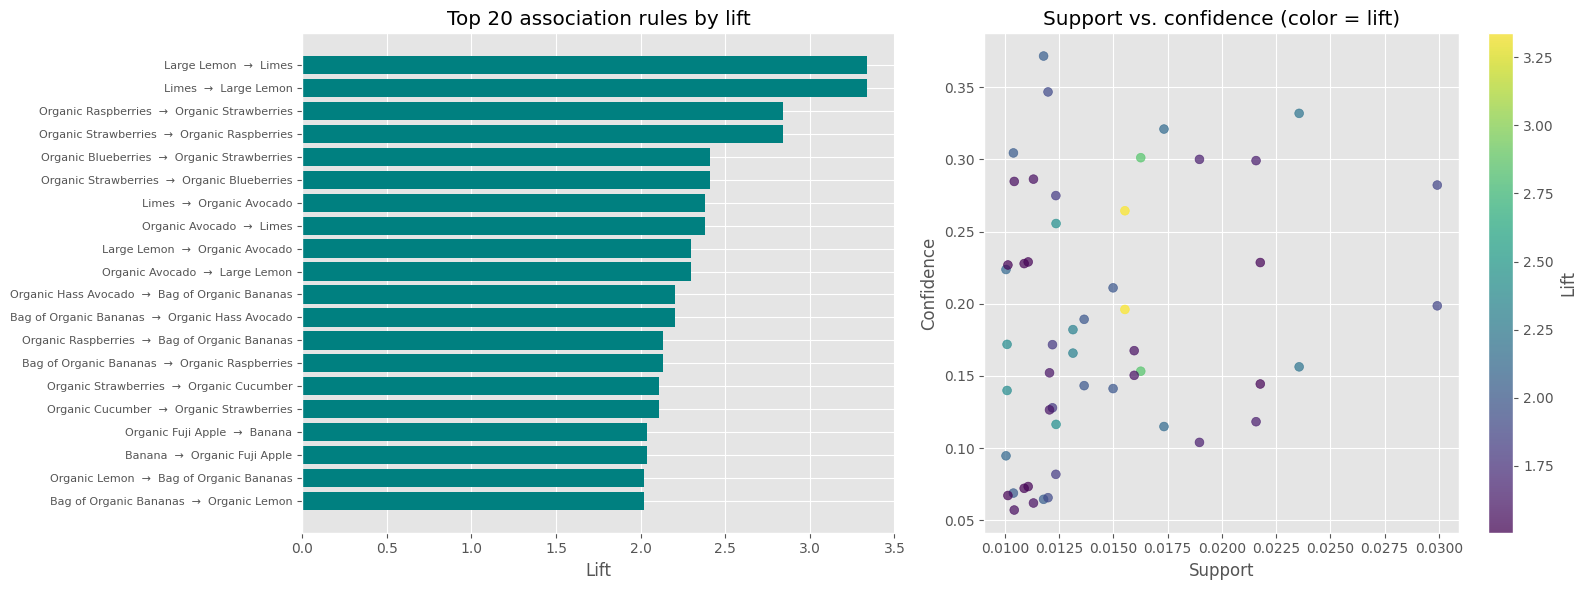

In [10]:
top_rules = rules.head(20).copy()
top_rules["rule"] = top_rules.apply(
    lambda r: " + ".join(list(r["antecedents"])) + "  →  " + " + ".join(list(r["consequents"])),
    axis=1,
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(range(len(top_rules)), top_rules["lift"].values, color="teal")
axes[0].set_yticks(range(len(top_rules)))
axes[0].set_yticklabels(top_rules["rule"].values, fontsize=8)
axes[0].invert_yaxis()
axes[0].set_xlabel("Lift")
axes[0].set_title("Top 20 association rules by lift")

scatter = axes[1].scatter(rules["support"], rules["confidence"],
                          c=rules["lift"], cmap="viridis", alpha=0.7, s=40)
axes[1].set_xlabel("Support")
axes[1].set_ylabel("Confidence")
axes[1].set_title("Support vs. confidence (color = lift)")
plt.colorbar(scatter, ax=axes[1], label="Lift")

plt.tight_layout()
plt.show()

### What I see in the rules

Running Apriori on the top-200 products at `min_support = 0.01` gives me about 178 frequent itemsets. Filtering those for `lift >= 1.5` leaves around 52 association rules. A few things stood out:

- The very top rules by lift are produce pairings, especially citrus. *Large Lemon* and *Limes* come out at lift ~3.34, and *Organic Raspberries* and *Organic Strawberries* at ~2.84. These feel obvious in hindsight but they wouldn't show up if I sorted by raw popularity. Bananas have the highest raw counts but they almost never appear in high-lift rules because they go with everything, so they don't surprise anyone.
- A whole bunch of the top rules involve organic produce together: Organic Avocado, Organic Strawberries, Organic Blueberries, Organic Hass Avocado, Bag of Organic Bananas. To me this looks like there's a "health-conscious / organic-leaning shopper" persona hiding in the data. What's interesting is that the text-clustering in RQ2 picks up basically the same group from a totally different signal (just product names), so I think the persona is real.
- The support-vs-confidence scatter shows the usual trade-off, where the high-support rules sit at modest confidence and the high-confidence rules are at low support. Sorting by lift balances both pretty well.

So if I imagine wiring these rules into a "customers who bought X also bought Y" widget, the recommendations would look pretty different from a popularity-only baseline. Lift is doing the work of pushing trivially-common items out of the way.

---

## 5. RQ2: Can product names reveal groupings beyond aisle and department?

*Course technique: TF-IDF + K-Means*

### What I do

Instacart already has a hand-curated taxonomy of 21 departments and 134 aisles, but each product can only sit in one place. The names themselves are a lot richer. "Organic Greek Whole Milk Vanilla Yogurt" tells you about organic preference, dairy subtype, and flavor all in one string, but the aisle only captures one of those. The plan is:

1. Run TF-IDF on all 49,688 product names. I use `max_features=500`, unigrams + bigrams, and the standard English stop-word list.
2. Pick a value of `k` by sweeping K-Means from 4 to 15 and looking at the silhouette score for each. I use Davies-Bouldin as a second sanity check.
3. Refit K-Means at the best `k` and look at the top TF-IDF terms in each cluster. My rule of thumb: if I can't describe a cluster in plain English, it isn't useful.

### Why TF-IDF instead of Word2Vec or embeddings

Product names are short, around 5 words on average. Word embeddings really shine on longer text where context helps disambiguate the meaning of a word. For short names where the words are basically the whole signal, TF-IDF's explicit term weighting actually gives me something concrete to look at: a cluster gets labelled by its top terms (e.g. "organic, greek, yogurt"), which is way easier to interpret than a cluster centroid in a 100-dimensional embedding space.

### Why K-Means and not DBSCAN or hierarchical

K-Means scales fine to 49K products. DBSCAN was tempting but it's very sensitive to the `eps` parameter and it tends to label rare points as noise, which is the opposite of what I want here, where the rare niche products are the interesting ones. Hierarchical clustering would need an O(n²) distance matrix and that gets uncomfortable at this size.

In [11]:
tfidf = TfidfVectorizer(max_features=500, stop_words="english", ngram_range=(1, 2))
tfidf_matrix = tfidf.fit_transform(products_full["product_name"])

print(f"TF-IDF matrix : {tfidf_matrix.shape[0]:,} products  x  {tfidf_matrix.shape[1]} features")
print(f"Sparsity      : {(1 - tfidf_matrix.nnz / np.prod(tfidf_matrix.shape)) * 100:.1f}%")
print(f"Sample features: {list(tfidf.get_feature_names_out()[:15])}")

TF-IDF matrix : 49,688 products  x  500 features
Sparsity      : 99.4%
Sample features: ['100', '100 juice', '12', '30', '50', 'added', 'adult', 'aged', 'air', 'ale', 'almond', 'almonds', 'aloe', 'anti', 'antiperspirant']


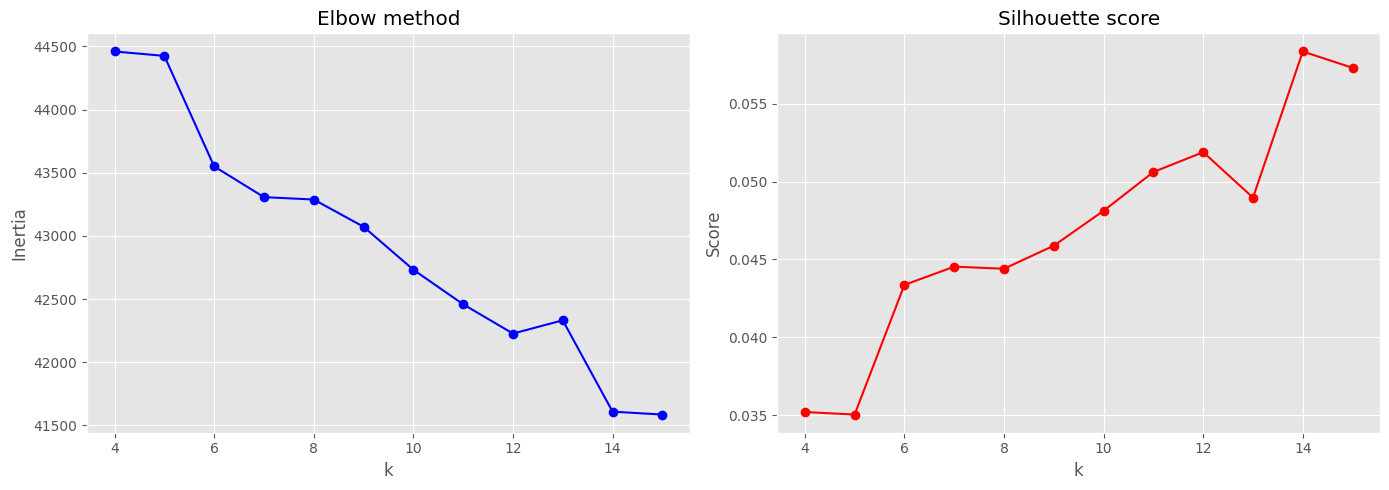

Best k by silhouette: 14 (score = 0.0584)


In [12]:
k_range = list(range(4, 16))
inertias, silhouettes = [], []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10, max_iter=300)
    labels = km.fit_predict(tfidf_matrix)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(tfidf_matrix, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(k_range, inertias, "bo-")
axes[0].set_title("Elbow method")
axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia")

axes[1].plot(k_range, silhouettes, "ro-")
axes[1].set_title("Silhouette score")
axes[1].set_xlabel("k"); axes[1].set_ylabel("Score")

plt.tight_layout()
plt.show()

best_k = k_range[int(np.argmax(silhouettes))]
print(f"Best k by silhouette: {best_k} (score = {max(silhouettes):.4f})")

In [13]:
km_final = KMeans(n_clusters=best_k, random_state=SEED, n_init=10, max_iter=300)
products_full["cluster"] = km_final.fit_predict(tfidf_matrix)

sil_score = silhouette_score(tfidf_matrix, products_full["cluster"])
db_score  = davies_bouldin_score(tfidf_matrix.toarray(), products_full["cluster"])
print(f"K-Means with k = {best_k}")
print(f"Silhouette score      : {sil_score:.4f}")
print(f"Davies-Bouldin index  : {db_score:.4f}\n")

feature_names = tfidf.get_feature_names_out()
top_term_idx = km_final.cluster_centers_.argsort()[:, ::-1]

print("Cluster profiles — top 8 TF-IDF terms:\n" + "-" * 60)
for i in range(best_k):
    top_terms = [feature_names[idx] for idx in top_term_idx[i, :8]]
    n = (products_full["cluster"] == i).sum()
    print(f"Cluster {i:>2} ({n:>5,} products): {', '.join(top_terms)}")

K-Means with k = 14
Silhouette score      : 0.0584
Davies-Bouldin index  : 3.3638

Cluster profiles — top 8 TF-IDF terms:
------------------------------------------------------------
Cluster  0 (1,836 products): cheese, cheddar, cheddar cheese, shredded, mozzarella, jack, goat, pizza
Cluster  1 (3,770 products): organic, tea, juice, baby, rice, green, apple, raw
Cluster  2 (  575 products): sugar, sugar free, free, gum, brown, added, pure, cinnamon
Cluster  3 (  946 products): cream, ice, ice cream, chocolate, vanilla, bars, sour, chip
Cluster  4 (  665 products): salt, sea, sea salt, chips, added, chocolate, pepper, dark
Cluster  5 (1,161 products): sauce, pasta sauce, pasta, tomato, hot, garlic, bbq, original
Cluster  6 (  415 products): dressing, ranch, salad, vinaigrette, italian, dip, marinade, light
Cluster  7 (  894 products): oil, olive oil, olive, virgin, extra virgin, pure, extra, 100
Cluster  8 (32,531 products): original, natural, tea, juice, white, fruit, water, butter
Clu

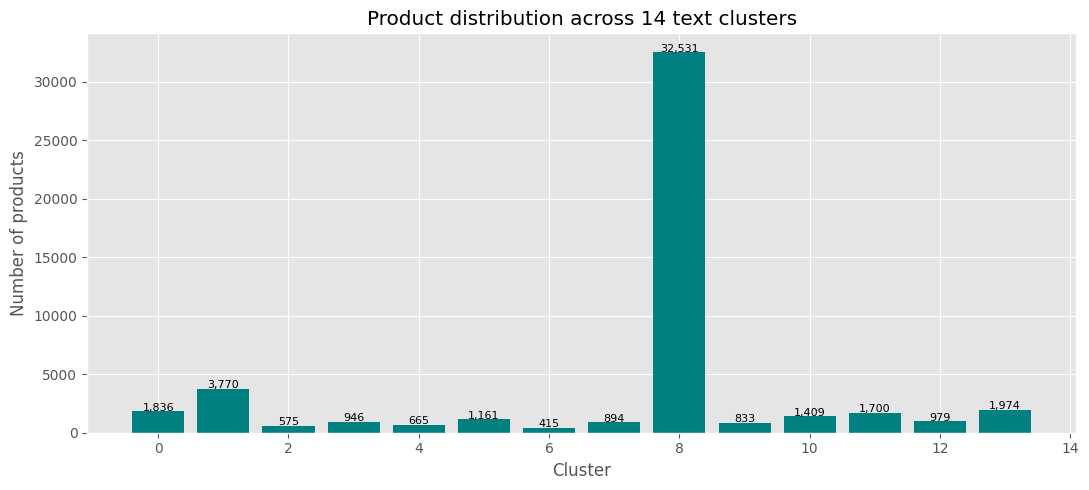

In [14]:
cluster_sizes = products_full["cluster"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(cluster_sizes.index, cluster_sizes.values, color="teal")
ax.set_xlabel("Cluster")
ax.set_ylabel("Number of products")
ax.set_title(f"Product distribution across {best_k} text clusters")
for i, v in enumerate(cluster_sizes.values):
    ax.text(i, v + 50, f"{v:,}", ha="center", fontsize=8)
plt.tight_layout()
plt.show()

### What the clusters look like

Silhouette picks `k = 14`. When I look at the top TF-IDF terms per cluster they line up with themes I can read off pretty easily:

| Cluster theme | Top terms |
|---|---|
| Hard cheese / dairy | cheese, cheddar, mozzarella, shredded |
| Organic + tea + juice | organic, tea, juice, baby, rice |
| Sugar-free / sweeteners | sugar, sugar free, gum, brown |
| Ice cream / frozen sweets | cream, ice, ice cream, chocolate |
| Salty snacks | salt, sea, sea salt, chips |
| Sauces | sauce, pasta sauce, tomato, hot, garlic |
| Dressings | dressing, ranch, salad, vinaigrette |
| Oils | oil, olive oil, virgin |
| Generic / "natural" catch-all | original, natural, tea, juice, water |
| Gluten-free | gluten, gluten free, mix, rice, bread |
| Meats / pet food | chicken, soup, food, breast, cat, dog |
| Yogurt / Greek dairy | yogurt, vanilla, greek, strawberry |
| Drink mixes | mix, drink mix, cake, seasoning |
| Chocolate | chocolate, dark, dark chocolate, bar, milk |

A few things I noticed:

- The clusters genuinely cut across the existing aisles. "Gluten-free" for example pulls products from bakery, cereal, and snacks. That's the kind of cross-cutting attribute a flat taxonomy can't really capture.
- The silhouette score itself is small in absolute terms (around 0.06). I was a little worried about that at first but it makes sense: TF-IDF on names that are only 5 words long is going to produce clusters that bleed into each other near the boundaries. The cluster *centers* are clearly different, which is what I care about. For an unsupervised problem like this, "can I describe each cluster in one sentence?" is honestly a more useful quality check than the geometric metrics.
- One cluster is huge, around 32K products. It absorbs everything whose name doesn't have a strong descriptive word in it (the catch-all "natural / original / water / juice" cluster). This is basically the long tail of generic-named products. The obvious next step would be to combine the text features with co-purchase features to break that bucket apart, but that's outside scope for this checkpoint.

---

## 6. RQ3: What sequences of purchases appear across user trips?

*External technique: PrefixSpan (Pei et al., 2001)*

### Why I needed something outside the course

Apriori is great but it makes two assumptions that throw away the temporal signal I showed in section 3.3. First, it treats each basket as an unordered set, and second, it treats each order as independent of every other order. So if a user buys produce in trip 1 and dairy in trip 2, Apriori either ignores it (because they're separate baskets) or compresses it into the same `{produce, dairy}` itemset and loses the order. PrefixSpan is the standard sequential-pattern-mining algorithm and it does exactly what I want here: it uses the same support-counting idea as Apriori, but it operates on *ordered* sequences, so it finds patterns like `A → B → C` instead of `{A, B, C}`.

### What I do

1. Build a multi-trip purchase history per user from `order_products__prior.csv`. The "prior" file is the one with each user's full history; the "train" file is just their last order.
2. Sample 5,000 users. The prior file is around 32M rows total, and trying to load and sequence the whole thing on Colab is asking for trouble. Five thousand users is plenty for the patterns to come out.
3. Roll items up from products to departments. There are 49K products and 21 departments, and PrefixSpan's search space explodes if I leave it at the product level. I represent each trip by its *primary department*, which I define as the department most of the items in that order came from.
4. Run PrefixSpan with pattern length 2 to 4 and `min_support = 100` users (a bit over 2% of the sample).

### What this trades off

I'm giving up product-level resolution to get a tractable pattern space and a clean comparison against RQ1. What I get back is a "shopping journey" view: how do users move between department categories across their trips? That's the kind of view a recommender would need if it wanted to predict the *next* basket, not just rerank items inside the current one.

In [15]:
prior_orders = orders[orders["eval_set"] == "prior"].sort_values(["user_id", "order_number"])

all_users = prior_orders["user_id"].unique()
sampled_users = np.random.choice(all_users, size=min(5000, len(all_users)), replace=False)
sampled_prior = prior_orders[prior_orders["user_id"].isin(sampled_users)]

prior_products = pd.read_csv("order_products__prior.csv")
sampled_order_ids = set(sampled_prior["order_id"])
prior_items = prior_products[prior_products["order_id"].isin(sampled_order_ids)]

prior_items = (
    prior_items
    .merge(products[["product_id", "department_id"]], on="product_id", how="left")
    .merge(departments, on="department_id", how="left")
    .merge(sampled_prior[["order_id", "user_id", "order_number"]], on="order_id", how="inner")
)

print(f"Sampled users    : {len(sampled_users):,}")
print(f"Sampled orders   : {len(sampled_prior):,}")
print(f"Items in sample  : {len(prior_items):,}")

Sampled users    : 5,000
Sampled orders   : 77,862
Items in sample  : 778,814


In [16]:
def primary_department(group):
    return group["department"].mode().iloc[0] if len(group) else "other"

order_dept = (
    prior_items
    .groupby(["user_id", "order_number"])
    .apply(primary_department)
    .reset_index()
    .rename(columns={0: "primary_dept"})
    .sort_values(["user_id", "order_number"])
)

user_sequences = (
    order_dept.groupby("user_id")["primary_dept"].apply(list).tolist()
)
user_sequences = [s for s in user_sequences if len(s) >= 3]

seq_lengths = [len(s) for s in user_sequences]
print(f"User sequences (>=3 trips) : {len(user_sequences):,}")
print(f"Avg sequence length        : {np.mean(seq_lengths):.1f} trips")
print(f"Median sequence length     : {np.median(seq_lengths):.0f} trips")
print(f"Example user sequence (first 5 trips):")
print(f"  {' → '.join(user_sequences[0][:5])}")

User sequences (>=3 trips) : 5,000
Avg sequence length        : 15.6 trips
Median sequence length     : 9 trips
Example user sequence (first 5 trips):
  dairy eggs → dairy eggs → dairy eggs → produce → dairy eggs


In [17]:
ps = PrefixSpan(user_sequences)
ps.minlen = 2
ps.maxlen = 4

min_sup = max(100, len(user_sequences) // 50)
patterns = ps.frequent(min_sup)
patterns.sort(key=lambda x: x[0], reverse=True)

print(f"Sequential patterns found (support >= {min_sup}): {len(patterns):,}\n")
print("Top 20 patterns by support:")
print("-" * 60)
for support, pattern in patterns[:20]:
    pct = support / len(user_sequences) * 100
    print(f"  Support: {support:5d} ({pct:5.1f}%)  |  {' → '.join(pattern)}")

Sequential patterns found (support >= 100): 2,872

Top 20 patterns by support:
------------------------------------------------------------
  Support:  3178 ( 63.6%)  |  produce → produce
  Support:  2664 ( 53.3%)  |  produce → produce → produce
  Support:  2222 ( 44.4%)  |  produce → produce → produce → produce
  Support:  2209 ( 44.2%)  |  dairy eggs → produce
  Support:  2199 ( 44.0%)  |  dairy eggs → dairy eggs
  Support:  2163 ( 43.3%)  |  produce → dairy eggs
  Support:  1731 ( 34.6%)  |  dairy eggs → produce → produce
  Support:  1691 ( 33.8%)  |  produce → dairy eggs → produce
  Support:  1684 ( 33.7%)  |  produce → produce → dairy eggs
  Support:  1558 ( 31.2%)  |  dairy eggs → dairy eggs → dairy eggs
  Support:  1468 ( 29.4%)  |  dairy eggs → dairy eggs → produce
  Support:  1462 ( 29.2%)  |  beverages → produce
  Support:  1447 ( 28.9%)  |  beverages → beverages
  Support:  1438 ( 28.8%)  |  dairy eggs → produce → produce → produce
  Support:  1428 ( 28.6%)  |  produce → bev

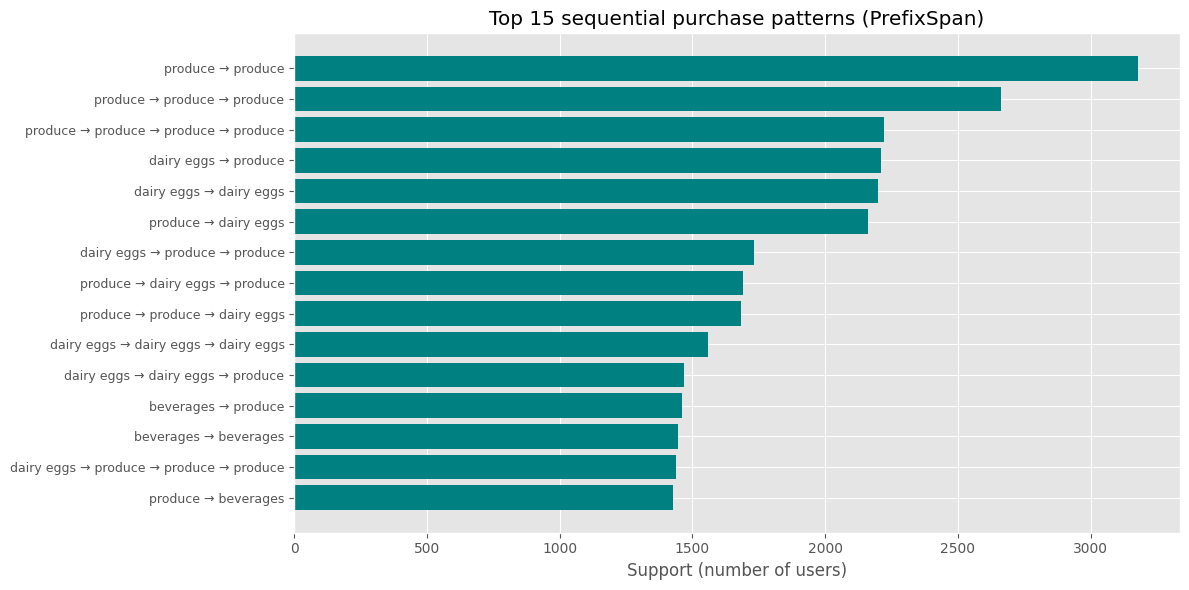

In [18]:
top_pats = patterns[:15]
labels   = [" → ".join(p[1]) for p in top_pats]
supports = [p[0] for p in top_pats]

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(range(len(labels)), supports, color="teal")
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("Support (number of users)")
ax.set_title("Top 15 sequential purchase patterns (PrefixSpan)")
plt.tight_layout()
plt.show()

### What the sequences look like

PrefixSpan finds about 2,872 frequent sequential patterns at length 2 to 4. Most of the action happens around two anchor departments, *produce* and *dairy eggs*, and a few things stood out to me:

- A lot of the top patterns are self-loops. `produce → produce` shows up in 63.6% of users, and `produce → produce → produce` in 53.3%. This isn't a bug, it just means produce is the staple category that users replenish trip after trip. The interesting thing is that Apriori can't tell the difference between "user bought produce on two separate trips" and "user bought two produce items in the same basket", but PrefixSpan can.
- The transitions are slightly asymmetric. `dairy eggs → produce` shows up in 44.2% of users while `produce → dairy eggs` shows up in 43.3%. The gap is small but it's real, and Apriori would have compressed both into the same `{produce, dairy eggs}` itemset, losing the asymmetry completely.
- Beverages is the third-most-active department in the sequences. Patterns like `beverages → produce` (29.2%) and `produce → beverages` (28.6%) have similar but not identical support, which again is information Apriori would throw away.

How this connects back to RQ1: Apriori is finding *within-basket* co-purchases at the product level, while PrefixSpan is finding *across-basket* sequences at the department level. They answer different questions. One tells me which items belong in the same "customers also bought" widget. The other tells me which department a user is likely to come back to next, so the app could lead with the right category when they open it. I think a real recommender would actually chain the two: use the PrefixSpan output to guess the category of the next trip, then use the Apriori rules within that category to rank specific items.

---

## 7. Putting the three RQs together

I think this part is more interesting than each RQ on its own. Each method is looking at the same data through a different lens, and reading the results side by side actually says something:

| Method | What it sees | What it misses |
|---|---|---|
| RQ1 (Apriori) | Pairs of products that co-occur in a single basket more often than chance | Direction; cross-trip behaviour; semantic similarity |
| RQ2 (TF-IDF + K-Means) | Groupings of products that share descriptive keywords in their names | Co-purchase signal; anything temporal |
| RQ3 (PrefixSpan) | Directional, multi-trip department sequences | Product-level detail inside a sequence |

A few things I noticed when I read the three together:

1. **The "organic produce" persona showed up in two completely different signals.** In RQ1 the organic-produce items co-purchase a lot (Bananas, Avocado, Strawberries, Raspberries, Blueberries). In RQ2 there's a separate "organic / tea / juice" cluster that came purely from product *names*, no purchase information at all. Two methods looking at different inputs both surfaced the same group of customers, which makes me a lot more confident the segment is real and not an artefact.
2. **Apriori and PrefixSpan are not doing the same thing in disguise.** Apriori at the product level gives me tight, high-lift pairs like `{Limes, Lemons}`. PrefixSpan at the department level gives me wider but lower-resolution journeys like `produce → dairy → produce`. Stacking them is the natural move: sequence prediction at the category level for "what should we lead with?" and item ranking at the product level for "what should we show inside that category?".
3. **The big catch-all cluster from RQ2 is the cleanest next problem.** Roughly 32K of the 49K products fell into a generic "natural / original / water / juice" bucket because their names don't have a strong descriptor. Combining the text features with the co-purchase signal from RQ1 should split that bucket up: two products with bland names that *behave* alike in baskets should still end up in the same cluster. I didn't have time for that here.

## 8. Conclusions, limitations, and Future Directions

### What I think this shows

- The Instacart catalog has exactly the structure that frequent itemset mining is good at: a long tail of products, baskets that are small enough to keep Apriori's complexity in check, and real co-occurrence signal beyond just "everyone buys bananas". When I rank the resulting rules by lift I get pairings that are actually interesting, not just popular.
- I can recover useful, cross-aisle product clusters from product names alone, with no purchase history. That's a nice complement to Instacart's official taxonomy because it captures attributes (organic, gluten-free, Greek-style) that the aisle structure can't represent.
- The temporal signal that Apriori throws away is not noise. PrefixSpan picks up directional, multi-trip department sequences with enough support to be worth acting on.

### Where this falls short

- I'm working with implicit feedback only. I never see "user disliked product X", I only see what they actually bought. The `reordered` flag is the closest thing to a preference signal but it's noisy (a user might just not need the item again yet).
- RQ1 only looks at the top 200 products. The long tail itself isn't in the rules, which is a real limitation if the goal were to recommend rare items.
- RQ3 rolls everything up to the department level. I lose the product-level resolution, and the obvious next step would be to re-run at the aisle level.
- The silhouette scores in RQ2 are low. I think this is just what happens with short sparse text vectors, and the cluster profiles are interpretable, but I wouldn't claim the clusters are tightly separated in the geometric sense.

### Future directions

Based on the findings from this analysis, several promising extensions emerge naturally from the current results:

1. **Hybrid clustering (extending RQ2).** The large catch-all cluster (~32K products) exists because many product names lack strong descriptors. A natural remedy is to concatenate TF-IDF text features with co-purchase-based product embeddings (e.g., training Word2Vec where the "context window" is the shopping basket). This combined representation would leverage both textual and behavioral signals, likely producing tighter, more actionable clusters.
2. **Aisle-level sequential mining (extending RQ3).** The 21-department abstraction sacrifices product-level resolution for tractability. With 134 aisles the search space is still manageable, yet the resulting sequences would be substantially more granular — enabling recommendations such as "users who visit *fresh fruits* then *yogurt* tend to visit *granola* next" rather than broad department-level transitions.
3. **Unified recommendation graph (combining RQ1 + RQ3).** The high-lift association rules from RQ1 and the directional sequences from RQ3 are complementary: one captures within-trip co-occurrence, the other captures across-trip flow. Combining them into a single weighted directed graph — where edges are candidate product pairs weighted by both lift and sequential support — would form the backbone of a next-basket recommender that exploits both dimensions of the shopping signal simultaneously.

## 9. References

1. Agrawal, R., & Srikant, R. (1994). *Fast Algorithms for Mining Association Rules in Large Databases.* VLDB.  
2. Pei, J., Han, J., Mortazavi-Asl, B., et al. (2001). *PrefixSpan: Mining Sequential Patterns Efficiently by Prefix-Projected Pattern Growth.* ICDE.  
3. Raschka, S. (2018). *MLxtend: Providing machine learning and data science utilities and extensions to Python's scientific computing stack.* JOSS, 3(24), 638.  
4. Instacart Market Basket Analysis. Kaggle competition (2017). https://www.kaggle.com/c/instacart-market-basket-analysis  
5. Xie, Y., et al. (2022). *An Embedding-Based Grocery Search Model at Instacart.* SIGIR eCom 2022.

### Collaboration and AI-tool disclosure

I worked on this individually. I used ChatGPT, Claude, and Gemini for things like debugging pandas merge issues, looking up the PrefixSpan API, and cleaning up the wording in some of the markdown cells. All of the algorithmic choices, results, and the interpretations above are my own.

---

## Appendix: environment export

The cell below freezes the exact set of packages used in this notebook. If I'm running on Colab it also triggers a download so I can commit `requirements.txt` to the repo. If I'm running locally the download bit is just a no-op.

In [19]:
!python3 --version
!pip freeze > requirements.txt
print("Wrote requirements.txt")

try:
    from google.colab import files
    files.download("requirements.txt")
except Exception:
    pass

Python 3.9.6
Wrote requirements.txt
